# v3 1st hidden layer — perturbation sweeps, accuracy

Visualises the **v3 factorial** grid: a per-pair spike ceiling `relu(count - k)`
setting temporal sparsity `a` along `k = 1, 2, 4, 8`, crossed with a
membrane-potential floor setting selectivity `s` (OFF / ON), at seeds 42/43/44 —
**24 checkpoints per arm, 8 setups × 3 seeds**, both arms, four eval-only
perturbations of the 1st hidden layer.

Each panel also carries the **non-sparse baseline** from `FWP_log/` — the
fixed-weight-perturbation network trained with *no sparsity penalty at all*, swept
over the same perturbations. It is the reference the whole sparsity gradient is
supposed to be read against: it says what an unconstrained network of this
architecture does.

This notebook plots **accuracy only**. The scoring, the regressions on `a` and
`s`, and the H1'/H2 verdict live in
[sparse_network_1stLayer_results_v3.md](../../../docs/legacy/sn_progress/sparse_network_1stLayer_results_v3.md)
and in `v3_analysis/phase1_regress.py`.

Every v3 point is the **mean over the cell's 3 seeds**; bands and error bars are the
across-seed standard deviation, read from the `per_setup` section of each results
file (the per-seed rows are kept in `per_checkpoint`). The baseline is a single
model per arm, with its own 3 perturbation repeats.

**Encoding.** `k` is an *ordered* variable, so it gets a single-hue ramp
(light → dark as `k` rises). The floor is *binary*, so it gets line style rather
than a hue. The baseline is not a cell of the factorial, so it takes neutral ink and
a dash-dot line rather than a colour slot — it reads as a reference, not a ninth
series.

| perturbation | what it destroys | rate-preserving? |
|---|---|---|
| relocation | spike placement, count held exactly | yes |
| jitter | spike placement, locally | yes |
| shift | cross-neuron alignment (rigid per-neuron translation) | yes |
| deletion | spikes themselves — the **general-robustness control** | **no** |

> **Two caveats on the baseline, both real.**
>
> 1. **The jitter panel is not strictly like-for-like.** The v3 jitter sweeps clip
>    jittered spikes to the layer's measured support `[0, 88)`; the baseline's jitter
>    (`exp_fixed_weight_perturbation/.../jitter_train.py`, generated 2026-07-15,
>    before that correction) clips to the full `[0, T-1]` window. Jitter is local, so
>    document 5 §2a measured the artifact at ≤ .026 — small, but it biases the
>    baseline *downward* relative to the v3 curves. Relocation is fine (the baseline
>    was regenerated 2026-07-31 with support-confined destinations), and shift and
>    deletion have no destination window to correct.
> 2. **Its clean accuracy differs slightly between the four files** (delay
>    .871–.890, no-delay .572–.584) because they come from separate runs of the same
>    non-sparse configuration. Each panel uses its own file's baseline, so every
>    panel is internally consistent; the clean-accuracy figure shows the range rather
>    than pretending there is one number.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Anchor on exp_sparse_network/ by walking up from wherever the notebook runs,
# so this works from the notebook's own directory or from the repo root.
def find_experiment_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "shd" / "log").is_dir() and (candidate / "sn_data").is_dir():
            return candidate
        nested = candidate / "my_project" / "exp_sparse_network"
        if (nested / "shd" / "log").is_dir():
            return nested
    raise FileNotFoundError("could not locate exp_sparse_network/")

EXP_DIR = find_experiment_root()
FWP_DIR = EXP_DIR / "result_visualization" / "1stLayer" / "FWP_log"
print(f"experiment root: {EXP_DIR}")
print(f"baseline logs  : {FWP_DIR}")

# (label, folder, v3 file stem, sweep key, baseline file template, x-axis label)
PERTURBATIONS = [
    ("relocation", "shd", "shd", "f_sweep",
     "shd_whole_{arm}_hidden_perturbation_results.json",
     "fraction of spikes relocated  f"),
    ("jitter", "jitter", "jitter", "sigma_sweep",
     "jitter_whole_{arm}_jitter_sweep_results.json",
     "jitter sigma  (ms)"),
    ("shift", "shift", "shift", "sigma_sweep",
     "shift_whole_{arm}_shift_sweep_results.json",
     "shift sigma  (ms)"),
    ("deletion", "deletion", "deletion", "pd_sweep",
     "deletion_whole_{arm}_evalOnly_deletion_sweep_results.json",
     "deletion probability  p_d"),
]
ARMS = [("nodelay", "no-delay arm"), ("delay", "with-delay arm")]

CHANCE = 1.0 / 20

# `k` is ordered -> one-hue ordinal ramp, light to dark. The floor is binary ->
# line style, not hue. Both palettes were validated against the light surface.
K_COLOURS = {1.0: "#86b6ef", 2.0: "#5598e7", 4.0: "#2a78d6", 8.0: "#184f95"}
FLOOR_STYLE = {0.0: dict(linestyle="--", marker="o", markerfacecolor="white"),
               1.0: dict(linestyle="-", marker="o")}
FLOOR_COLOUR = {0.0: "#2a78d6", 1.0: "#eb6834"}

INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

# The non-sparse baseline is a reference, not a series: neutral ink, dash-dot.
BASELINE_STYLE = dict(color=INK, linestyle="-.", marker="s", markersize=4.5,
                      linewidth=2.2, zorder=5)


def load_per_setup(arm: str, folder: str, stem: str) -> dict:
    '''Return the seed-averaged v3 rows for one arm and one perturbation.'''
    path = EXP_DIR / folder / "log" / f"sparse_whole_{arm}_v3_{stem}_eval.json"
    return json.loads(path.read_text())["per_setup"]


def load_baseline(arm: str, template: str) -> dict:
    '''Return the non-sparse sweep: {grid point (float) -> (mean, std)}.'''
    raw = json.loads((FWP_DIR / template.format(arm=arm)).read_text())
    return {float(point): (entry["mean"], entry["std"])
            for point, entry in raw.items()}


def style_axis(axis) -> None:
    '''Recessive grid and spines, so the data carries the ink.'''
    axis.grid(True, color=GRID, linewidth=0.6, alpha=0.9)
    axis.set_axisbelow(True)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color(GRID)
    axis.tick_params(colors=INK_MUTED, labelsize=9)


# Check that all eight v3 files and all eight baseline files are present.
for arm, _ in ARMS:
    for label, folder, stem, field, template, _ in PERTURBATIONS:
        rows = load_per_setup(arm, folder, stem)
        seeds = {row["n_seeds"] for row in rows.values()}
        baseline = load_baseline(arm, template)
        print(f"{arm:<8} {label:<11} v3: {len(rows)} setups, seeds {seeds}"
              f"   |  baseline: {len(baseline)} points, "
              f"clean {baseline[min(baseline)][0]:.3f}")

experiment root: D:\IC_2025\IRP\workspace\my_project\exp_sparse_network
baseline logs  : D:\IC_2025\IRP\workspace\my_project\exp_sparse_network\result_visualization\1stLayer\FWP_log
nodelay  relocation  v3: 8 setups, seeds {3}   |  baseline: 11 points, clean 0.584
nodelay  jitter      v3: 8 setups, seeds {3}   |  baseline: 7 points, clean 0.572
nodelay  shift       v3: 8 setups, seeds {3}   |  baseline: 7 points, clean 0.572
nodelay  deletion    v3: 8 setups, seeds {3}   |  baseline: 5 points, clean 0.573
delay    relocation  v3: 8 setups, seeds {3}   |  baseline: 11 points, clean 0.890
delay    jitter      v3: 8 setups, seeds {3}   |  baseline: 7 points, clean 0.874
delay    shift       v3: 8 setups, seeds {3}   |  baseline: 7 points, clean 0.874
delay    deletion    v3: 8 setups, seeds {3}   |  baseline: 5 points, clean 0.871


## 1. Accuracy against perturbation magnitude

Rows are the two arms, columns the four perturbations. All eight panels share
one y-axis so the arms can be compared directly — the no-delay arm simply starts
much lower.

Reading the panels: the **spread between the coloured curves** is what the factorial
is about, and **the gap to the black baseline** is what the sparsity penalty cost.
A panel where the eight coloured curves lie on top of each other says the
perturbation does not distinguish the cells.

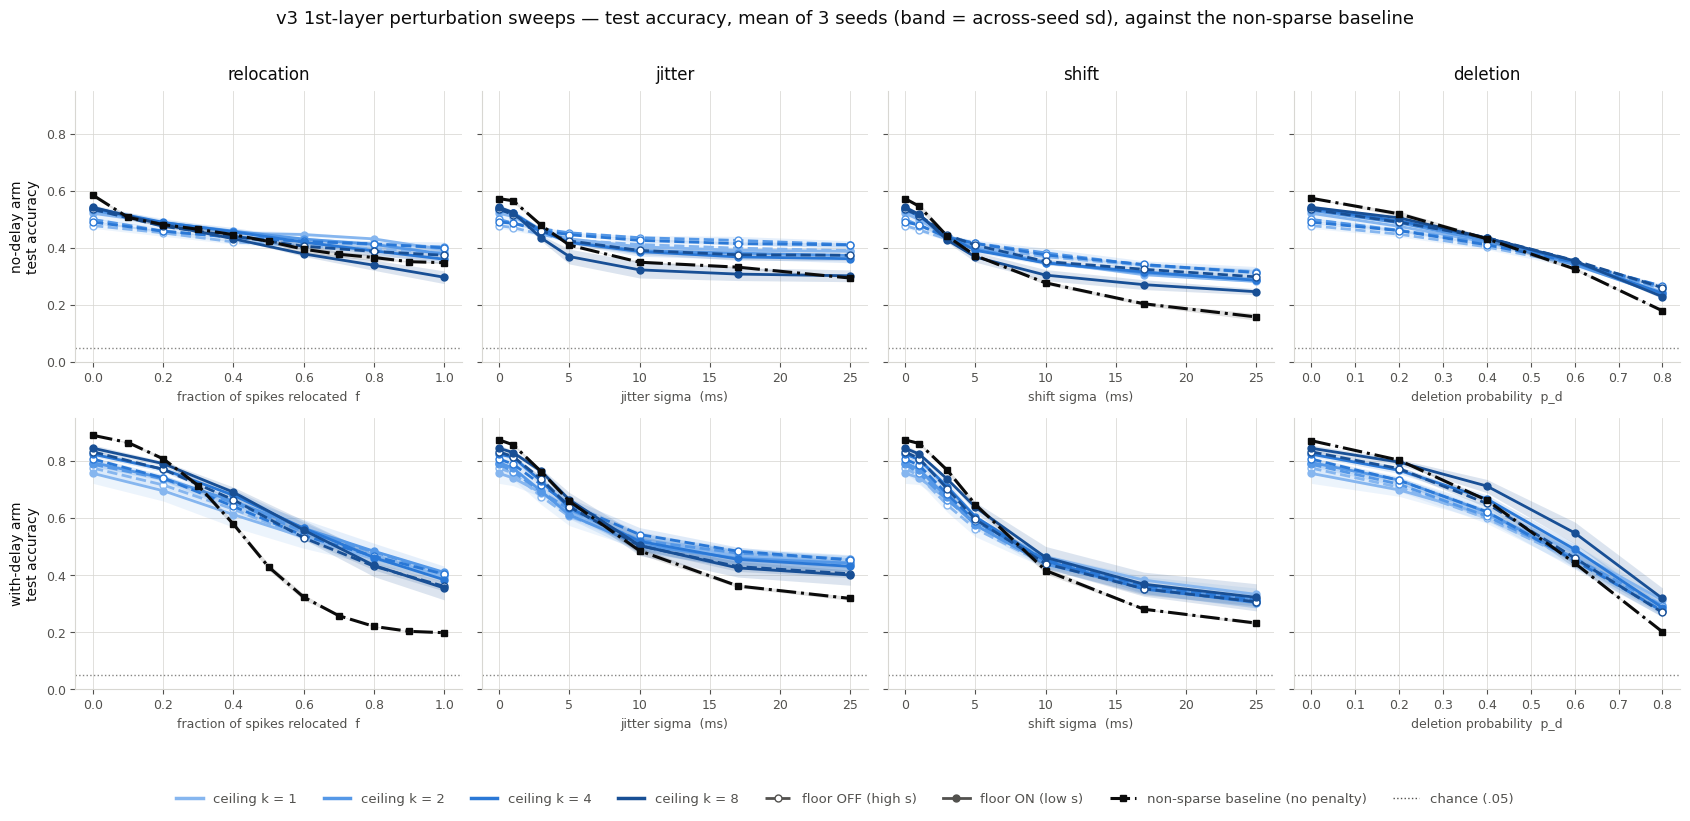

In [2]:
figure, axes = plt.subplots(2, 4, figsize=(17, 8), sharey=True)

for row, (arm, arm_label) in enumerate(ARMS):
    for col, (label, folder, stem, field, template, xlabel) in enumerate(PERTURBATIONS):
        axis = axes[row][col]
        for entry in load_per_setup(arm, folder, stem).values():
            grid = [float(point) for point in entry[field]]
            means = np.array([entry[field][p]["mean"] for p in entry[field]])
            stds = np.array([entry[field][p]["std"] for p in entry[field]])
            colour = K_COLOURS[entry["ceiling_k"]]
            axis.plot(grid, means, color=colour, linewidth=2, markersize=5,
                      markeredgecolor=colour, **FLOOR_STYLE[entry["floor_strength"]])
            axis.fill_between(grid, means - stds, means + stds,
                              color=colour, alpha=0.15, linewidth=0)

        baseline = load_baseline(arm, template)
        points = sorted(baseline)
        base_means = np.array([baseline[p][0] for p in points])
        base_stds = np.array([baseline[p][1] for p in points])
        axis.plot(points, base_means, **BASELINE_STYLE)
        axis.fill_between(points, base_means - base_stds, base_means + base_stds,
                          color=INK, alpha=0.12, linewidth=0, zorder=4)

        axis.axhline(CHANCE, color=INK_MUTED, linewidth=1, linestyle=":", alpha=0.7)
        style_axis(axis)
        axis.set_xlabel(xlabel, fontsize=9, color=INK_MUTED)
        if col == 0:
            axis.set_ylabel(f"{arm_label}\ntest accuracy", fontsize=10, color=INK)
        if row == 0:
            axis.set_title(label, fontsize=12, color=INK, pad=8)

axes[0][0].set_ylim(0.0, 0.95)

handles = [plt.Line2D([], [], color=colour, linewidth=2.5, label=f"ceiling k = {k:g}")
           for k, colour in K_COLOURS.items()]
handles += [
    plt.Line2D([], [], color=INK_MUTED, linewidth=2, linestyle="--", marker="o",
               markerfacecolor="white", markersize=5, label="floor OFF (high s)"),
    plt.Line2D([], [], color=INK_MUTED, linewidth=2, linestyle="-", marker="o",
               markersize=5, label="floor ON (low s)"),
    plt.Line2D([], [], label="non-sparse baseline (no penalty)", **BASELINE_STYLE),
    plt.Line2D([], [], color=INK_MUTED, linewidth=1, linestyle=":",
               label="chance (.05)"),
]
figure.legend(handles=handles, loc="lower center", ncol=8, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.03))
figure.suptitle("v3 1st-layer perturbation sweeps — test accuracy, "
                "mean of 3 seeds (band = across-seed sd), against the "
                "non-sparse baseline", fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.06, 1, 0.97))
plt.show()

## 2. Clean accuracy across the grid

The unperturbed baseline each curve above starts from. Worth reading before any
perturbation result: a normalised damage score divides by this number, so a cell
whose clean accuracy is unusual will move the score for reasons that have nothing
to do with timing.

The grey band is the non-sparse network's clean accuracy — a **band** rather than a
line because the four baseline files were produced by separate runs and disagree by
about .02 (delay) and .01 (no-delay). The distance from the band down to the bars is
the accuracy the sparsity penalty costs.

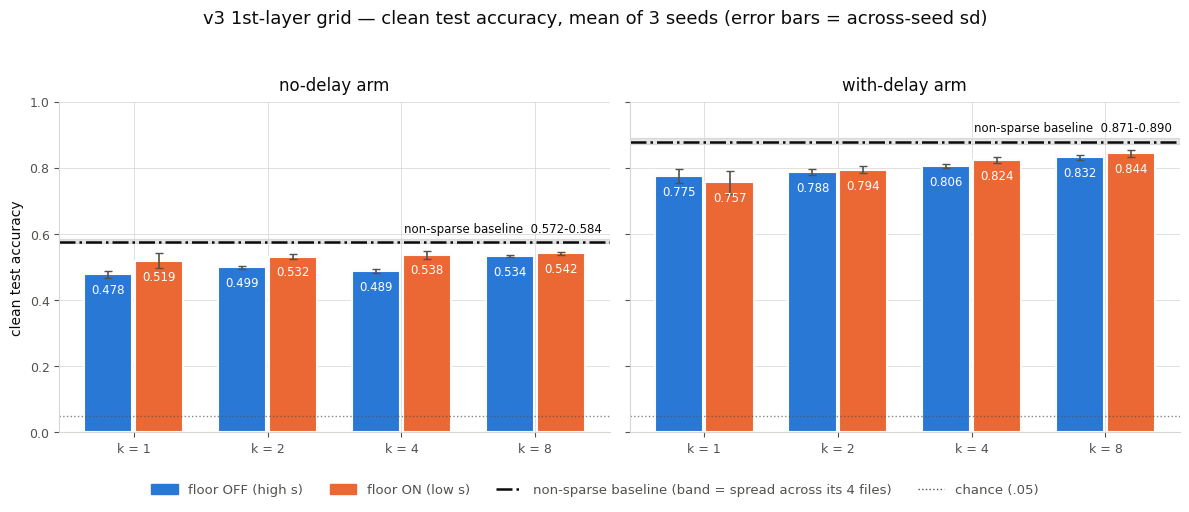

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
k_levels = [1.0, 2.0, 4.0, 8.0]
positions = np.arange(len(k_levels))
width = 0.36
baseline_ranges = {}

for col, (arm, arm_label) in enumerate(ARMS):
    axis = axes[col]
    per_setup = load_per_setup(arm, "shd", "shd")

    # Non-sparse reference: every baseline file's own clean accuracy.
    clean_baselines = [load_baseline(arm, template)[0.0][0]
                       for *_, template, _ in PERTURBATIONS]
    low, high = min(clean_baselines), max(clean_baselines)
    baseline_ranges[arm] = (low, high)
    axis.axhspan(low, high, color=INK, alpha=0.10, zorder=0)
    axis.axhline(float(np.mean(clean_baselines)), color=INK, linestyle="-.",
                 linewidth=1.8, zorder=1)
    axis.text(len(k_levels) - 0.5, high + 0.012,
              f"non-sparse baseline  {low:.3f}-{high:.3f}", ha="right",
              va="bottom", fontsize=8.5, color=INK)

    for index, floor in enumerate([0.0, 1.0]):
        rows = [per_setup[f"k{k:g}_floor{floor:g}"] for k in k_levels]
        means = [row["clean_acc"] for row in rows]
        errs = [row["clean_acc_std"] for row in rows]
        offset = (index - 0.5) * (width + 0.02)
        axis.bar(positions + offset, means, width, yerr=errs, capsize=3,
                 color=FLOOR_COLOUR[floor], edgecolor="#fcfcfb", linewidth=1.5,
                 error_kw=dict(ecolor=INK_MUTED, lw=1.2), zorder=2)
        # Values sit inside the bar, so they cannot collide with the baseline.
        for position, value in zip(positions + offset, means):
            axis.text(position, value - 0.028, f"{value:.3f}", ha="center",
                      va="top", fontsize=8.5, color="#ffffff", zorder=3)

    axis.axhline(CHANCE, color=INK_MUTED, linewidth=1, linestyle=":", alpha=0.7)
    axis.set_xticks(positions)
    axis.set_xticklabels([f"k = {k:g}" for k in k_levels])
    style_axis(axis)
    axis.set_title(arm_label, fontsize=12, color=INK, pad=8)
    if col == 0:
        axis.set_ylabel("clean test accuracy", fontsize=10, color=INK)

axes[0].set_ylim(0.0, 1.0)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[0.0], label="floor OFF (high s)"),
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[1.0], label="floor ON (low s)"),
    plt.Line2D([], [], color=INK, linestyle="-.", linewidth=1.8,
               label="non-sparse baseline (band = spread across its 4 files)"),
    plt.Line2D([], [], color=INK_MUTED, linewidth=1, linestyle=":",
               label="chance (.05)"),
]
figure.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.06))
figure.suptitle("v3 1st-layer grid — clean test accuracy, mean of 3 seeds "
                "(error bars = across-seed sd)", fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.02, 1, 0.94))
plt.show()

## 3. The same numbers as a table

Kept so the figures are never the only way to read the result, and so exact
values can be quoted without measuring pixels. The `baseline` row of each arm is the
non-sparse network at the same endpoints.

In [4]:
header = (f"{'arm':<15}{'setup':<12}{'clean acc':>16}{'a':>7}{'s':>8}"
          f"{'reloc(1)':>10}{'jit(25)':>9}{'shift(25)':>10}{'del(.8)':>9}")
print(header)
print("-" * len(header))

for arm, arm_label in ARMS:
    per_setup = load_per_setup(arm, "shd", "shd")
    sweeps = {label: load_per_setup(arm, folder, stem)
              for label, folder, stem, _, _, _ in PERTURBATIONS}
    for tag, entry in per_setup.items():
        endpoints = []
        for label, _, _, field, _, _ in PERTURBATIONS:
            sweep = sweeps[label][tag][field]
            endpoints.append(sweep[list(sweep)[-1]]["mean"])
        clean = f"{entry['clean_acc']:.3f}+-{entry['clean_acc_std']:.3f}"
        print(f"{arm_label:<15}{tag:<12}{clean:>16}"
              f"{entry['spikes_per_active_neuron']:>7.2f}"
              f"{entry['silent_fraction']:>8.3f}"
              f"{endpoints[0]:>10.3f}{endpoints[1]:>9.3f}"
              f"{endpoints[2]:>10.3f}{endpoints[3]:>9.3f}")

    base_endpoints, base_cleans = [], []
    for label, _, _, _, template, _ in PERTURBATIONS:
        baseline = load_baseline(arm, template)
        base_cleans.append(baseline[0.0][0])
        base_endpoints.append(baseline[max(baseline)][0])
    clean = f"{np.mean(base_cleans):.3f}({min(base_cleans):.3f}-{max(base_cleans):.3f})"
    print(f"{arm_label:<15}{'BASELINE':<12}{clean:>16}{'--':>7}{'--':>8}"
          f"{base_endpoints[0]:>10.3f}{base_endpoints[1]:>9.3f}"
          f"{base_endpoints[2]:>10.3f}{base_endpoints[3]:>9.3f}")
    print()

arm            setup              clean acc      a       s  reloc(1)  jit(25) shift(25)  del(.8)
------------------------------------------------------------------------------------------------
no-delay arm   k1_floor0       0.478+-0.010   2.33   0.753     0.383    0.390     0.316    0.256
no-delay arm   k1_floor1       0.519+-0.023   1.88   0.191     0.393    0.388     0.282    0.244
no-delay arm   k2_floor0       0.499+-0.006   2.41   0.692     0.403    0.411     0.314    0.258
no-delay arm   k2_floor1       0.532+-0.008   2.10   0.130     0.377    0.373     0.288    0.235
no-delay arm   k4_floor0       0.489+-0.006   2.71   0.588     0.399    0.410     0.313    0.265
no-delay arm   k4_floor1       0.538+-0.012   2.75   0.084     0.360    0.361     0.286    0.240
no-delay arm   k8_floor0       0.534+-0.002   3.47   0.467     0.373    0.373     0.298    0.260
no-delay arm   k8_floor1       0.542+-0.005   3.97   0.058     0.297    0.302     0.246    0.228
no-delay arm   BASELINE    0.5